# Homework 4.1 — Instrumental variables

## tl;dr

| Quiz question | Answer | Evidence |
|---|---|---|
| Q1: Effect using the first averaging method | **C — 1.5** | Wald estimate = **1.561859** |
| Q2: Was W needed for that calculation? | **A — No** | The first method uses only Z, X, and Y |

For the second method, the equal-weight average of estimates in 20 W intervals
is **1.505526**. That method does require W. Questions 3–5 are in
`homework_4.2_regression_discontinuity.ipynb`.

## Context & Methods

Source: `homework_4.1.csv` in the project folder. X is treatment, W is the
confounder, Y is the outcome, and the binary Z is the instrument.
Use all 5,000 observations.

**Method 1: difference of overall means, then ratio (Wald estimator).**

$$\widehat\tau_{IV}=
\frac{\overline Y_{Z=1}-\overline Y_{Z=0}}
     {\overline X_{Z=1}-\overline X_{Z=0}}.$$

**Method 2: ratio within each W interval, then average those ratios.**

$$\widehat\tau_b=\frac{\overline Y_{Z=1,b}-\overline Y_{Z=0,b}}
{\overline X_{Z=1,b}-\overline X_{Z=0,b}},\qquad
\widehat\tau_{stratified}=\frac{1}{B}\sum_{b=1}^B\widehat\tau_b.$$

Use 20 equal-count W intervals (250 rows per interval). These give narrow
ranges where W is dense and wider ranges in the tails, preserving every row
and avoiding very sparse tail bins. This is an explicit binning choice, not
a unique answer prescribed by the quiz. Also compare 10 and 40 intervals.
The second calculation is a **mean of ratios**, rather than a ratio of pooled differences.

### Key Assumptions

- Z must affect X (relevance), affect Y only through X (exclusion), and be
  independent of unmeasured outcome causes for the intended IV interpretation.
- The first method needs a valid instrument without conditioning on W. If
  instrument validity holds only conditional on W, simply omitting W is not justified.
- A common linear treatment effect supports interpreting the ratio as that
  effect. With heterogeneous effects, an IV estimand need not be the overall
  population average treatment effect.
- Every W interval must contain both instrument levels and a nonzero X difference.
  Very small denominators make interval-specific ratios unstable.

Setup if needed: `%pip install numpy pandas scipy matplotlib scikit-learn`.
Keep the CSV in the project folder above `Homework Code`.

## Data

### 1. Set up the analysis

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

pd.set_option('display.precision', 6)
plt.rcParams.update({
    'figure.figsize': (9, 4.8), 'figure.dpi': 110, 'font.size': 11,
    'axes.titlesize': 13, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E5E7EB', 'axes.axisbelow': True,
    'text.color': '#1F2937', 'axes.labelcolor': '#1F2937',
})
BLUE, GOLD, DARK = '#2563EB', '#B7791F', '#374151'

def locate_csv(filename):
    # Works from the project folder, Homework Code, or HW4.
    for folder in (Path.cwd(), *Path.cwd().parents):
        path = folder / filename
        if path.is_file():
            return path.resolve()
    raise FileNotFoundError(f'Cannot find {filename} above the working directory.')

def show_table(frame, formats=None):
    display(frame.style.hide(axis='index').format(formats or {}, na_rep='—'))

def validate_numeric(frame):
    if not all(pd.api.types.is_numeric_dtype(frame[c]) for c in frame):
        raise TypeError('All analysis columns must be numeric.')
    if not np.isfinite(frame.to_numpy()).all():
        raise ValueError('Missing or infinite analysis values.')

### 2. Load and validate the CSV

In [2]:
DATA_PATH = locate_csv('homework_4.1.csv')
data = pd.read_csv(DATA_PATH)
required = ['Z', 'W', 'X', 'Y']
if not set(required).issubset(data.columns):
    raise ValueError(f'Required columns: {required}')
data = data[required].copy()
validate_numeric(data)
assert set(data['Z'].unique()) == {0, 1}
print(f'Source: {DATA_PATH.name}; rows: {len(data):,}; missing values: 0')
print('SHA-256:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())
display(data.head())

Source: homework_4.1.csv; rows: 5,000; missing values: 0
SHA-256: 0cf5f0d0380a2591dd5f9411933466eb488f5bd77832d3fa16638addcb5a5832


,Z,W,X,Y
0,0,-0.155644,-0.496971,0.282484
1,1,0.529539,2.284240,4.740596
2,1,0.910514,0.872232,3.449569
3,1,-0.705476,2.157260,3.002531
4,0,-0.590874,-0.386730,-1.848796


## Results

### 3. Q1 — Compute the overall Wald estimate

In [3]:
# W is deliberately absent from this calculation.
overall_means = data.groupby('Z')[['X', 'Y']].mean()
instrument_counts = data.groupby('Z').size()
mean_table = overall_means.rename(columns={'X': 'Mean X', 'Y': 'Mean Y'})
mean_table.insert(0, 'Observations', instrument_counts)
show_table(mean_table.reset_index(), {'Mean X': '{:.6f}', 'Mean Y': '{:.6f}'})

delta_y = overall_means.loc[1, 'Y'] - overall_means.loc[0, 'Y']
delta_x = overall_means.loc[1, 'X'] - overall_means.loc[0, 'X']
if np.isclose(delta_x, 0):
    raise ValueError('The Wald denominator is zero or numerically negligible.')
wald_effect = delta_y / delta_x
show_table(pd.DataFrame({
    'Quantity': ['Y difference', 'X difference', 'IV effect: Y difference / X difference'],
    'Value': [delta_y, delta_x, wald_effect],
}), {'Value': '{:.6f}'})

options = {'A': 2.0, 'B': 0.5, 'C': 1.5, 'D': 1.0}
closest_option = min(options, key=lambda key: abs(options[key] - wald_effect))
display(Markdown(f'**Q1: {closest_option} — {options[closest_option]:.1f}.** '
                 f'The estimate is {wald_effect:.6f}.'))

Z,Observations,Mean X,Mean Y
0,2493,-0.009363,-0.057371
1,2507,1.009196,1.533474


Quantity,Value
Y difference,1.590845
X difference,1.018559
IV effect: Y difference / X difference,1.561859


**Q1: C — 1.5.** The estimate is 1.561859.

### 4. Visualize the differences induced by the instrument

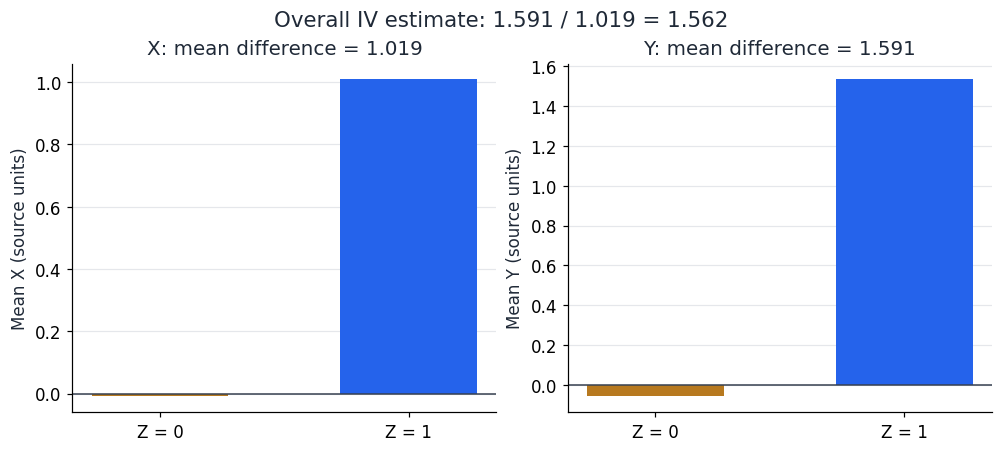

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
for ax, outcome, difference in zip(axes, ['X', 'Y'], [delta_x, delta_y]):
    ax.bar([0, 1], overall_means[outcome], color=[GOLD, BLUE], width=0.55)
    ax.axhline(0, color=DARK, linewidth=1)
    ax.set_xticks([0, 1], ['Z = 0', 'Z = 1'])
    ax.set_ylabel(f'Mean {outcome} (source units)')
    ax.set_title(f'{outcome}: mean difference = {difference:.3f}')
    ax.grid(axis='x', visible=False)
fig.suptitle(f'Overall IV estimate: {delta_y:.3f} / {delta_x:.3f} = {wald_effect:.3f}',
             fontsize=14)
plt.show()

### 5. Q2 — Identify whether W is needed

In [5]:
display(Markdown('**Q2: A — No.** Method 1 groups observations only by Z and '
    'computes means of X and Y. W is needed for Method 2 because its intervals '
    'define the groups used in that calculation.'))

**Q2: A — No.** Method 1 groups observations only by Z and computes means of X and Y. W is needed for Method 2 because its intervals define the groups used in that calculation.

### 6. Calculate effects within W intervals

In [6]:
def effects_by_w(frame, number_of_bins):
    working = frame.assign(w_bin=pd.qcut(frame['W'], q=number_of_bins))
    grouped = working.groupby(['w_bin', 'Z'], observed=True)
    means = grouped[['X', 'Y']].mean().unstack('Z')
    counts = grouped.size().unstack('Z', fill_value=0)
    if not (counts > 0).all().all():
        raise ValueError('A W interval does not contain both instrument levels.')
    differences_x = means['X'][1] - means['X'][0]
    differences_y = means['Y'][1] - means['Y'][0]
    if np.isclose(differences_x, 0).any():
        raise ValueError('An interval has a numerically negligible first-stage difference.')
    result = pd.DataFrame({
        'W interval': means.index.astype(str),
        'Mean W': working.groupby('w_bin', observed=True)['W'].mean().to_numpy(),
        'N (Z=0)': counts[0].to_numpy(), 'N (Z=1)': counts[1].to_numpy(),
        'Delta X': differences_x.to_numpy(), 'Delta Y': differences_y.to_numpy(),
        'IV effect': (differences_y / differences_x).to_numpy(),
    })
    assert result[['N (Z=0)', 'N (Z=1)']].to_numpy().sum() == len(frame)
    return result

N_BINS = 20
bin_results = effects_by_w(data, N_BINS)
stratified_effect = bin_results['IV effect'].mean()
show_table(bin_results, {c: '{:.4f}' for c in ['Mean W', 'Delta X', 'Delta Y', 'IV effect']})
print(f'Equal-weight average across {N_BINS} W intervals: {stratified_effect:.6f}')
print(f'Smallest absolute X difference: {bin_results["Delta X"].abs().min():.6f}')

W interval,Mean W,N (Z=0),N (Z=1),Delta X,Delta Y,IV effect
"(-3.304, -1.584]",-2.0064,137,113,0.9666,1.6319,1.6882
"(-1.584, -1.277]",-1.4180,125,125,1.1224,1.5155,1.3502
"(-1.277, -1.042]",-1.1544,130,120,1.0562,1.3879,1.3141
"(-1.042, -0.855]",-0.9484,121,129,0.9149,1.1792,1.2890
"(-0.855, -0.698]",-0.7756,129,121,0.9940,1.6182,1.6280
"(-0.698, -0.547]",-0.6223,133,117,0.9661,1.5410,1.5951
"(-0.547, -0.401]",-0.4743,119,131,0.9279,1.5593,1.6804
"(-0.401, -0.277]",-0.3382,121,129,0.8338,1.2940,1.5519
"(-0.277, -0.149]",-0.2111,134,116,0.9414,1.3080,1.3894
"(-0.149, -0.0322]",-0.0902,116,134,1.0553,1.5827,1.4998


Equal-weight average across 20 W intervals: 1.505526
Smallest absolute X difference: 0.833818


Each interval has both Z levels, all 5,000 rows are included, and the smallest X difference is about 0.834. No interval has a near-zero denominator in this calculation. The conditional average, 1.505526, is also close to 1.5.

### 7. Inspect interval estimates and binning sensitivity

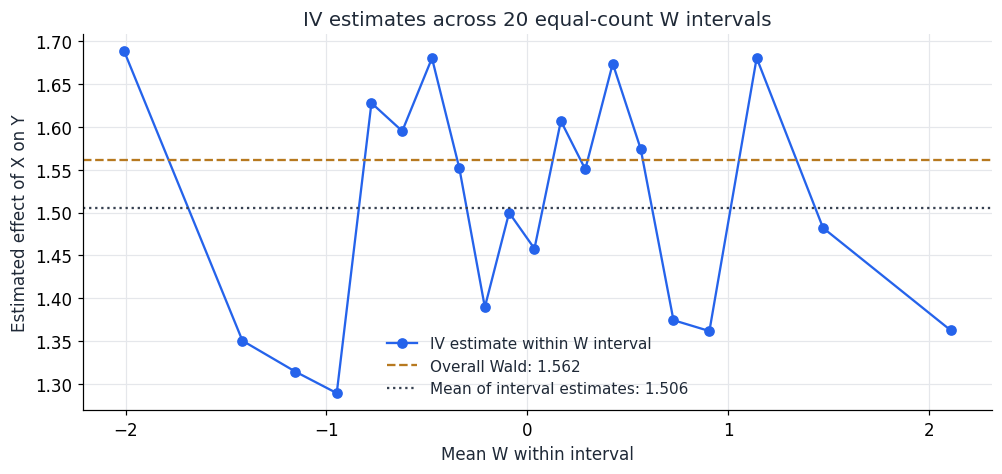

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
ax.plot(bin_results['Mean W'], bin_results['IV effect'], 'o-', color=BLUE,
        label='IV estimate within W interval', linewidth=1.5)
ax.axhline(wald_effect, color=GOLD, linestyle='--', label=f'Overall Wald: {wald_effect:.3f}')
ax.axhline(stratified_effect, color=DARK, linestyle=':',
           label=f'Mean of interval estimates: {stratified_effect:.3f}')
ax.set_xlabel('Mean W within interval')
ax.set_ylabel('Estimated effect of X on Y')
ax.set_title('IV estimates across 20 equal-count W intervals')
ax.legend(frameon=False, fontsize=10)
plt.show()

In [8]:
sensitivity = []
for number in [10, 20, 40]:
    result = effects_by_w(data, number)
    sensitivity.append({
        'W intervals': number, 'Rows per interval': len(data) // number,
        'Mean IV effect': result['IV effect'].mean(),
        'Smallest absolute Delta X': result['Delta X'].abs().min(),
    })
show_table(pd.DataFrame(sensitivity), {
    'Mean IV effect': '{:.6f}', 'Smallest absolute Delta X': '{:.6f}'
})

W intervals,Rows per interval,Mean IV effect,Smallest absolute Delta X
10,500,1.508896,0.880740
20,250,1.505526,0.833818
40,125,1.510400,0.663936


### 8. Independently verify the overall ratio

In [9]:
from sklearn.linear_model import LinearRegression

# With a binary instrument and an intercept, the two-stage coefficient equals Wald.
first_stage = LinearRegression().fit(data[['Z']], data['X'])
predicted_x = first_stage.predict(data[['Z']])
second_stage = LinearRegression().fit(predicted_x.reshape(-1, 1), data['Y'])
np.testing.assert_allclose(second_stage.coef_[0], wald_effect, atol=1e-12)

# Cov(Z, Y) / Cov(Z, X) gives the same just-identified IV point estimate.
covariance_ratio = (np.cov(data['Z'], data['Y'], ddof=1)[0, 1]
                    / np.cov(data['Z'], data['X'], ddof=1)[0, 1])
np.testing.assert_allclose(covariance_ratio, wald_effect, atol=1e-12)
assert closest_option == 'C'
print('Checks passed: binary-instrument Wald ratio, covariance ratio, and two-stage coefficient.')

Checks passed: binary-instrument Wald ratio, covariance ratio, and two-stage coefficient.


## Takeaways

Select **Q1: C — 1.5** and **Q2: A — No**. The overall estimate is **1.561859**, computed without W. The second method uses W and gives **1.505526** with the stated 20-interval specification.

### Reproducibility

In [10]:
print('Python:', platform.python_version())
for package in ['numpy', 'pandas', 'scipy', 'matplotlib', 'scikit-learn']:
    print(f'{package}: {importlib.metadata.version(package)}')

Python: 3.13.5
numpy: 2.4.1
pandas: 3.0.0
scipy: 1.17.0
matplotlib: 3.10.8
scikit-learn: 1.8.0
